# Project Introduction

In today’s digital banking environment, a huge volume of customer transactions is generated every day. Analyzing these transactions helps banks understand customer behavior, monitor spending patterns, detect unusual activities, and make data-driven business decisions.

This project, Customer Banking Transaction Analysis, focuses on exploring and analyzing banking transaction data to extract meaningful insights using data analysis techniques. The analysis helps in understanding how customers interact with banking services through deposits, withdrawals, transfers, and other transaction activities.

# Dataset Overview

The dataset used in this project represents customer-level banking transaction records. Each row in the dataset corresponds to a single transaction performed by a customer. The dataset contains information such as customer details, transaction type, transaction amount, transaction date, and account-related attributes.

This dataset is suitable for Exploratory Data Analysis (EDA) as it allows analysis of:

- Customer transaction behavior

- Frequency and type of transactions

- Credit vs debit patterns

- High-value and low-value transactions

- Monthly or time-based transaction trends

Before performing analysis, the dataset is checked for missing values, duplicates, and data inconsistencies to ensure accurate and reliable insights.

In [1]:
# import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
n = 5000 #no of rows in dataset

In [3]:
np.random.seed(42) # for reproducibility

df = pd.DataFrame({

    "transaction_id": range(1, n + 1),

    "customer_id": np.random.randint(1001, 1501, size=n),

    "transaction_type": np.random.choice(
        ["Debit", "Credit"],
        size=n,
        p=[0.6, 0.4]
    ),

    "amount": np.round(
        np.random.normal(loc=2500, scale=1800, size=n), 2
    ),

    "channel": np.random.choice(
        ["ATM", "UPI", "Card", "NetBanking",],
        size=n,
        p=[0.25, 0.35, 0.25, 0.15]
    ),

    "merchant_category": np.random.choice(
        ["Grocery", "Shopping", "Fuel", "Bills", "Entertainment"],
        size=n
    ),

    "transaction_month": np.random.choice(
        ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"],
        size=n
    )
})

# 10 missing values in transaction_type
df.loc[
    np.random.choice(df.index, size=10, replace=False),
    'transaction_type'
] = np.nan

# 20 missing values in amount
df.loc[
    np.random.choice(df.index, size=20, replace=False),
    'amount'
] = np.nan



In [4]:
df

,transaction_id,customer_id,transaction_type,amount,channel,merchant_category,transaction_month
0,1,1103,Credit,3734.54,UPI,Grocery,Jan
1,2,1436,Credit,-1376.72,Card,Bills,Sep
2,3,1349,Debit,3304.57,UPI,Bills,Jun
3,4,1271,Credit,1350.55,ATM,Shopping,Apr
4,5,1107,Debit,5475.96,NetBanking,Fuel,Dec
...,...,...,...,...,...,...,...
4995,4996,1111,Credit,652.76,ATM,Grocery,Jun
4996,4997,1415,Debit,3598.42,UPI,Shopping,Mar
4997,4998,1290,Credit,3354.54,UPI,Grocery,Nov
4998,4999,1295,Credit,3179.60,UPI,Grocery,Aug


# Shape & Structure

In [5]:
df.shape

(5000, 7)

In [6]:
df.columns

Index(['transaction_id', 'customer_id', 'transaction_type', 'amount',
       'channel', 'merchant_category', 'transaction_month'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   transaction_id     5000 non-null   int64  
 1   customer_id        5000 non-null   int32  
 2   transaction_type   4990 non-null   object 
 3   amount             4980 non-null   float64
 4   channel            5000 non-null   object 
 5   merchant_category  5000 non-null   object 
 6   transaction_month  5000 non-null   object 
dtypes: float64(1), int32(1), int64(1), object(4)
memory usage: 254.0+ KB


In [8]:
df.head()

,transaction_id,customer_id,transaction_type,amount,channel,merchant_category,transaction_month
0,1,1103,Credit,3734.54,UPI,Grocery,Jan
1,2,1436,Credit,-1376.72,Card,Bills,Sep
2,3,1349,Debit,3304.57,UPI,Bills,Jun
3,4,1271,Credit,1350.55,ATM,Shopping,Apr
4,5,1107,Debit,5475.96,NetBanking,Fuel,Dec


In [9]:
df.tail()

,transaction_id,customer_id,transaction_type,amount,channel,merchant_category,transaction_month
4995,4996,1111,Credit,652.76,ATM,Grocery,Jun
4996,4997,1415,Debit,3598.42,UPI,Shopping,Mar
4997,4998,1290,Credit,3354.54,UPI,Grocery,Nov
4998,4999,1295,Credit,3179.60,UPI,Grocery,Aug
4999,5000,1451,Debit,2172.33,UPI,Bills,Mar


In [10]:
df.describe()

,transaction_id,customer_id,amount
count,5000.000000,5000.000000,4980.000000
mean,2500.500000,1251.670600,2484.644179
std,1443.520003,144.570083,1805.806982
min,1.000000,1001.000000,-4560.320000
25%,1250.750000,1128.000000,1263.407500
50%,2500.500000,1253.000000,2471.545000
75%,3750.250000,1379.000000,3714.650000
max,5000.000000,1500.000000,8852.300000


**The dataset contains 5,000 rows and 7 columns, comprising both numerical and categorical features. Initial inspection indicates consistent data types, along with some missing and inconsistent values that will be addressed during the data cleaning stage.**

# Data Cleaning

In [11]:
# Check missing values
df.isnull().sum()

transaction_id        0
customer_id           0
transaction_type     10
amount               20
channel               0
merchant_category     0
transaction_month     0
dtype: int64

In [12]:
# Filling missing transaction types using the mode
df['transaction_type'].fillna(
    df['transaction_type'].mode()[0],
    inplace=True)

In [13]:
# Filling missing amount values using the median
df['amount'].fillna(
    df['amount'].median(),
    inplace=True)


In [14]:
# Re-checking missing values to confirm successful imputation
df.isnull().sum()

transaction_id       0
customer_id          0
transaction_type     0
amount               0
channel              0
merchant_category    0
transaction_month    0
dtype: int64

**A final null value check confirms that all missing values have been successfully handled, ensuring a complete dataset for subsequent analysis.**

In [15]:
# Check duplicates
df.duplicated().sum()

0

In [16]:
df

,transaction_id,customer_id,transaction_type,amount,channel,merchant_category,transaction_month
0,1,1103,Credit,3734.54,UPI,Grocery,Jan
1,2,1436,Credit,-1376.72,Card,Bills,Sep
2,3,1349,Debit,3304.57,UPI,Bills,Jun
3,4,1271,Credit,1350.55,ATM,Shopping,Apr
4,5,1107,Debit,5475.96,NetBanking,Fuel,Dec
...,...,...,...,...,...,...,...
4995,4996,1111,Credit,652.76,ATM,Grocery,Jun
4996,4997,1415,Debit,3598.42,UPI,Shopping,Mar
4997,4998,1290,Credit,3354.54,UPI,Grocery,Nov
4998,4999,1295,Credit,3179.60,UPI,Grocery,Aug


In [17]:
# correcting negative transaction amounts
df["amount"] = df["amount"].abs()

In [18]:
df["amount"]

0       3734.54
1       1376.72
2       3304.57
3       1350.55
4       5475.96
         ...   
4995     652.76
4996    3598.42
4997    3354.54
4998    3179.60
4999    2172.33
Name: amount, Length: 5000, dtype: float64

**Negative transaction amounts were treated as data inconsistencies and corrected.**

In [42]:
# Ensuring Transaction ID Uniqueness
df["transaction_id"].is_unique

True

**Each transaction is uniquely identified, confirming data integrity at the transaction level.**

# Descriptive Statistics

In [19]:
df["amount"].describe()

count    5000.000000
mean     2621.071718
std      1597.164098
min         1.600000
25%      1353.665000
50%      2478.090000
75%      3712.800000
max      8852.300000
Name: amount, dtype: float64

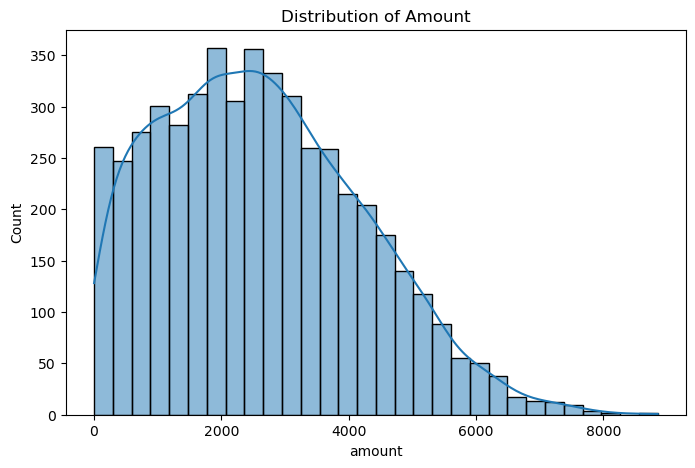

In [20]:
# Amount distribution analysis
plt.figure(figsize=(8,5))
sns.histplot(df['amount'], bins=30, kde=True)
plt.title("Distribution of Amount")
plt.show()

**Transaction amounts are right-skewed, with most values concentrated in the mid-range and a small number of high-value transactions influencing the overall mean.**
**The mean being higher than the median confirms that extreme high values are influencing the overall average.**

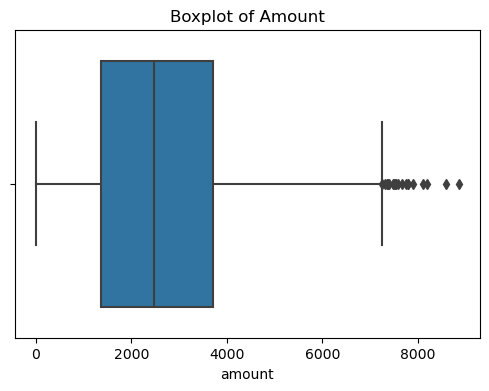

In [21]:
# Outlier detection using boxplot
plt.figure(figsize=(6,4))
sns.boxplot(x=df['amount'])
plt.title("Boxplot of Amount")
plt.show()


**A few high-value outliers are present, while most transactions lie in a moderate range.**

# Outlier analysis

In [22]:
Q1 = df['amount'].quantile(0.25)
Q3 = df['amount'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['amount'] < lower) | (df['amount'] > upper)]
outliers.shape


(20, 7)

**Using the IQR method, 20 records were identified as outliers in the transaction amount, indicating a small number of extreme high-value transactions compared to the overall dataset.**

In [23]:
# Remove outliers
df = df[(df['amount'] >= lower) & (df['amount'] <= upper)]


In [24]:
df['amount']

0       3734.54
1       1376.72
2       3304.57
3       1350.55
4       5475.96
         ...   
4995     652.76
4996    3598.42
4997    3354.54
4998    3179.60
4999    2172.33
Name: amount, Length: 4980, dtype: float64

**Extreme values were removed as they were not representative of normal transaction behavior.**

In [33]:
# Recalculate IQR after outlier removal
Q1 = df['amount'].quantile(0.25)
Q3 = df['amount'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['amount'] < lower) | (df['amount'] > upper)]
outliers.shape

(3, 7)

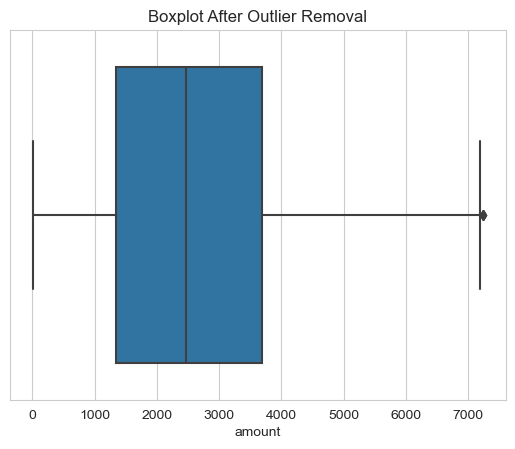

In [34]:
sns.boxplot(x=df['amount'])
plt.title("Boxplot After Outlier Removal")
plt.show()


**No points outside whiskers = success.**

# Amount vs Transaction Type

In [35]:
df.groupby('transaction_type')['amount'].mean()

transaction_type
Credit    2643.829516
Debit     2573.496042
Name: amount, dtype: float64

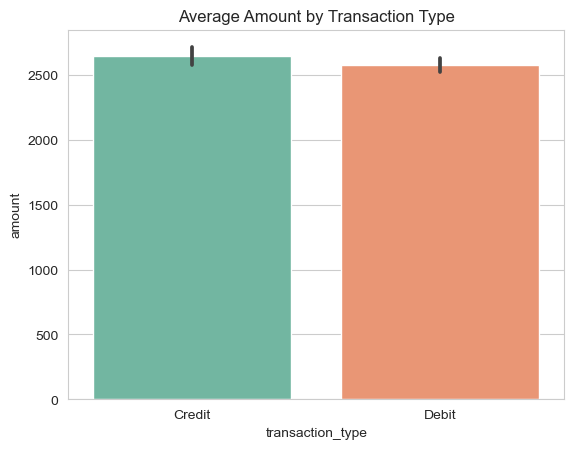

In [36]:
sns.barplot(data=df, x='transaction_type', y='amount',  palette='Set2')
plt.title("Average Amount by Transaction Type")
plt.show()

- Credit transactions have a slightly higher average amount than Debit transactions.
- The difference is not very large, which suggests:
- Customers spend similar amounts using both modes.
- Credit is used a bit more for higher-value transactions.

# Channel-wise Analysis

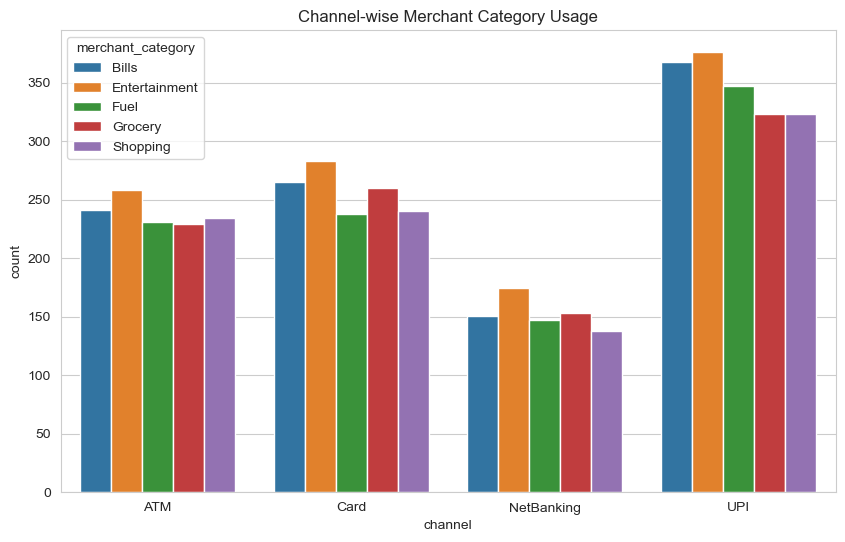

In [44]:
# Visualizing channel-wise distribution of merchant categories
channel_merchant = (
    df.groupby(['channel', 'merchant_category']).size().reset_index(name='count')
)

plt.figure(figsize=(10,6))
sns.barplot(
    data=channel_merchant,
    x='channel',
    y='count',
    hue='merchant_category'
)
plt.title("Channel-wise Merchant Category Usage")
plt.show()


- UPI dominates across all merchant categories.
- Entertainment & Bills have the highest transactions.
- Card is the second most used channel.
- NetBanking shows minimal usage.
- Fuel & Grocery are evenly spread across channels.

# Category-wise Amount

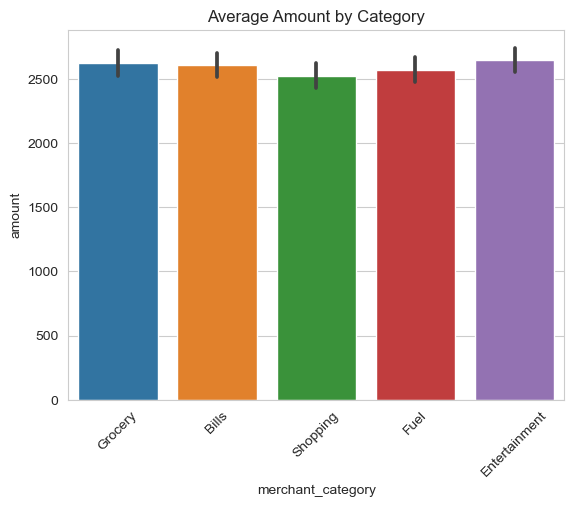

In [38]:
sns.barplot(data=df, x='merchant_category', y='amount')
plt.xticks(rotation=45)
plt.title("Average Amount by Category")
plt.show()

- Entertainment has the highest average transaction amount, followed closely by Grocery and Bills.
- Shopping shows the lowest average amount, indicating smaller but frequent purchases.
- Overall, average spend is fairly consistent across categories.

# Time-based Trend

In [39]:
month_order = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

monthly_avg = (
    df.groupby('transaction_month')['amount'].mean().reindex(month_order)
)

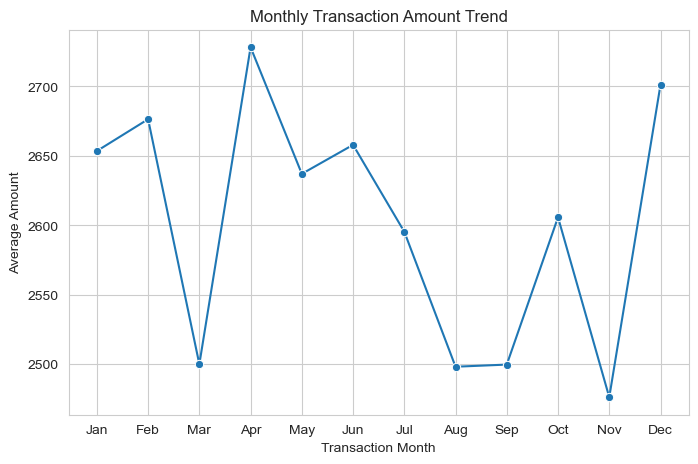

In [40]:
sns.set_style("whitegrid")
plt.figure(figsize=(8,5))

sns.lineplot(
    x=monthly_avg.index,
    y=monthly_avg.values,
    marker='o'
)

plt.title("Monthly Transaction Amount Trend")
plt.xlabel("Transaction Month")
plt.ylabel("Average Amount")
plt.show()


**The trend indicates moderate volatility, suggesting seasonal spending patterns rather than a consistent upward or downward trend.**

# Customer-Level Analysis

In [54]:
# Calculate average transaction amount per customer
avg_per_customer= df.groupby("customer_id")["amount"].mean().sort_values(ascending=False).head(10)

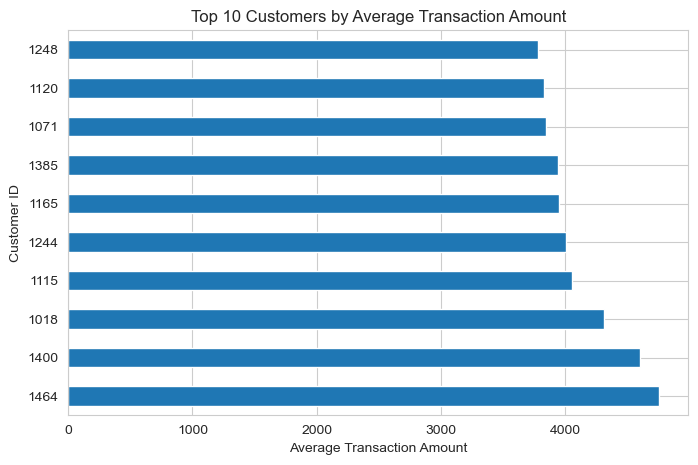

In [56]:
plt.figure(figsize=(8, 5))
avg_per_customer.plot(kind="barh")
plt.title("Top 10 Customers by Average Transaction Amount")
plt.xlabel("Average Transaction Amount")
plt.ylabel("Customer ID")
plt.show()


- Only a few customers show higher average transaction amounts.
- The majority of customers have relatively lower average transaction values.
- Customer spending behavior varies significantly across individuals.

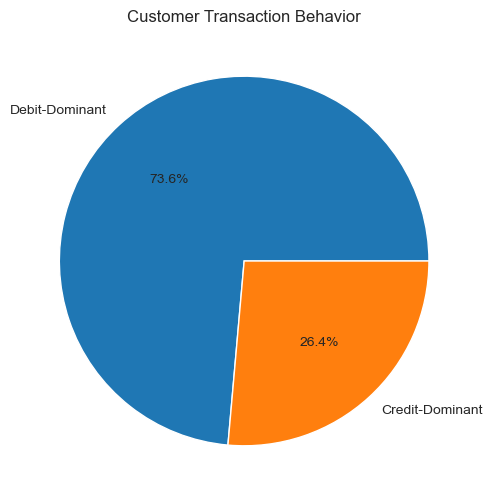

In [62]:
# Customer-level credit vs debit score
cust = df.pivot_table(
    index="customer_id",
    columns="transaction_type",
    values="amount",
    aggfunc="sum",
    fill_value=0
)

cust["type"] = (cust.get("Credit", 0) > cust.get("Debit", 0)) \
               .map({True: "Credit-Dominant", False: "Debit-Dominant"})

# Pie chart
cust["type"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6, 6),
    title="Customer Transaction Behavior"
)

plt.ylabel("")
plt.show()


- Around 74% of customers are debit-dominant, indicating that most customers use their accounts primarily for spending.
- Only 26% of customers are credit-dominant, reflecting a smaller segment with stronger inflow-oriented transaction behavior.

# Anomaly Pattern Exploration

In [65]:
# Define anomaly threshold (99th percentile)
threshold = df["amount"].quantile(0.99)

# Flag anomalies
df["is_anomaly"] = df["amount"] > threshold

# View anomaly countZS
df["is_anomaly"].value_counts()


is_anomaly
False    4930
True       50
Name: count, dtype: int64

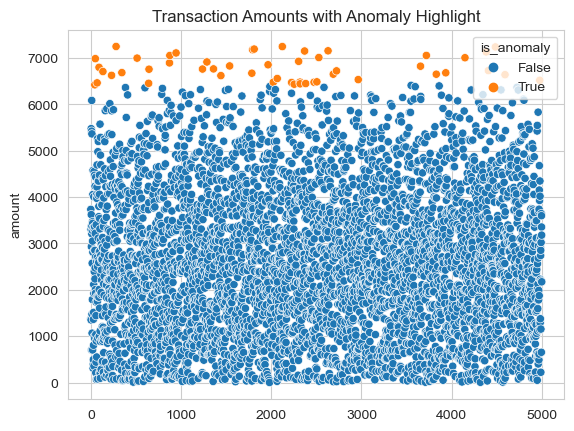

In [67]:
sns.scatterplot(
    x=df.index,
    y=df["amount"],
    hue=df["is_anomaly"]
)
plt.title("Transaction Amounts with Anomaly Highlight")
plt.show()


**Only a small fraction of transactions fall above the 99th percentile, indicating rare high-value activity that should be monitored closely.**

In [70]:
df

,transaction_id,customer_id,transaction_type,amount,channel,merchant_category,transaction_month,amount_bucket,is_anomaly
0,1,1103,Credit,3734.54,UPI,Grocery,Jan,High,False
1,2,1436,Credit,1376.72,Card,Bills,Sep,Medium,False
2,3,1349,Debit,3304.57,UPI,Bills,Jun,High,False
3,4,1271,Credit,1350.55,ATM,Shopping,Apr,Medium,False
4,5,1107,Debit,5475.96,NetBanking,Fuel,Dec,High,False
...,...,...,...,...,...,...,...,...,...
4995,4996,1111,Credit,652.76,ATM,Grocery,Jun,Low,False
4996,4997,1415,Debit,3598.42,UPI,Shopping,Mar,High,False
4997,4998,1290,Credit,3354.54,UPI,Grocery,Nov,High,False
4998,4999,1295,Credit,3179.60,UPI,Grocery,Aug,High,False


# Project Conclusion

This project analyzed banking transaction data to understand customer-level behavior, transaction patterns, and potential anomalies.
Through exploratory data analysis, transactions were examined by type (credit/debit), channel, merchant category, and amount buckets to identify key contribution patterns.

Customer-level analysis revealed distinct credit-dominant and debit-dominant users, helping segment customers based on spending behavior. Contribution analysis highlighted how transaction types, channels, and merchants influence overall transaction volume.

Anomaly detection was performed using a statistical threshold (99th percentile of transaction amount) to flag unusually high-value transactions. These rare transactions can be useful for monitoring, risk analysis, and further investigation.

Overall, the project demonstrates a structured data analysis workflow—from data preparation and visualization to behavioral insights and anomaly exploration—providing meaningful business-ready insights from transactional data.

